In [ ]:
#Teste 1 do modelo de AI: Verificação de hardware e criação da arquitetura de previsão com LSTM.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras #type: ignore
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping

# 1. VERIFICAÇÃO DE HARDWARE (RTX 3050)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Sucesso! GPU detectada: {gpus}")
else:
    print("GPU não detectada. O treino será na CPU (mais lento).")

# 2. DEFINIÇÃO DA ARQUITETURA "ANTI-RUÍDO"
# Focamos em eficiência: ~40k parâmetros em vez de 100k neurônios soltos. Nesse sentido, evitamos a captura de ruído!
def build_financial_model(input_shape):
    model = keras.Sequential([
        # Camada 1: LSTM para memória sequencial
        layers.LSTM(units=64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.25), 
        
        # Camada 2: Refinamento de padrões
        layers.LSTM(units=32, return_sequences=False),
        layers.Dropout(0.25),
        
        # Camada de decisão (Densa)
        layers.Dense(units=16, activation='relu'),
        layers.Dense(units=1) # Saída única: Predição do próximo retorno
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# 3. EXEMPLO DE FLUXO DE DADOS
# window_size = 60 dias de histórico para prever o próximo
window_size = 60
n_features = 1 # Ex: apenas Retorno Logarítmico

model = build_financial_model((window_size, n_features))

# 4. CALLBACK DE EARLY STOPPING (O "seguro" contra overfitting)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10,        # Se em 10 épocas o erro não cair, ele para
    restore_best_weights=True
)

print("\n--- Estrutura do Modelo ---")
model.summary()

GPU não detectada. O treino será na CPU (mais lento).

--- Estrutura do Modelo ---


c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

[*********************100%***********************]  9 of 9 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_2600\3926350690.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()


--- Calibrando modelos GARCH (Risk Engine) ---


C:\Users\henri\AppData\Local\Temp\ipykernel_2600\3926350690.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_2600\3926350690.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_2600\3926350690.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'


--- Iniciando Walk-Forward (2022-2026) ---

--- Resultado Final (Pipeline MLP + GARCH + HRP) ---
Sharpe Ratio Anualizado: 0.4239


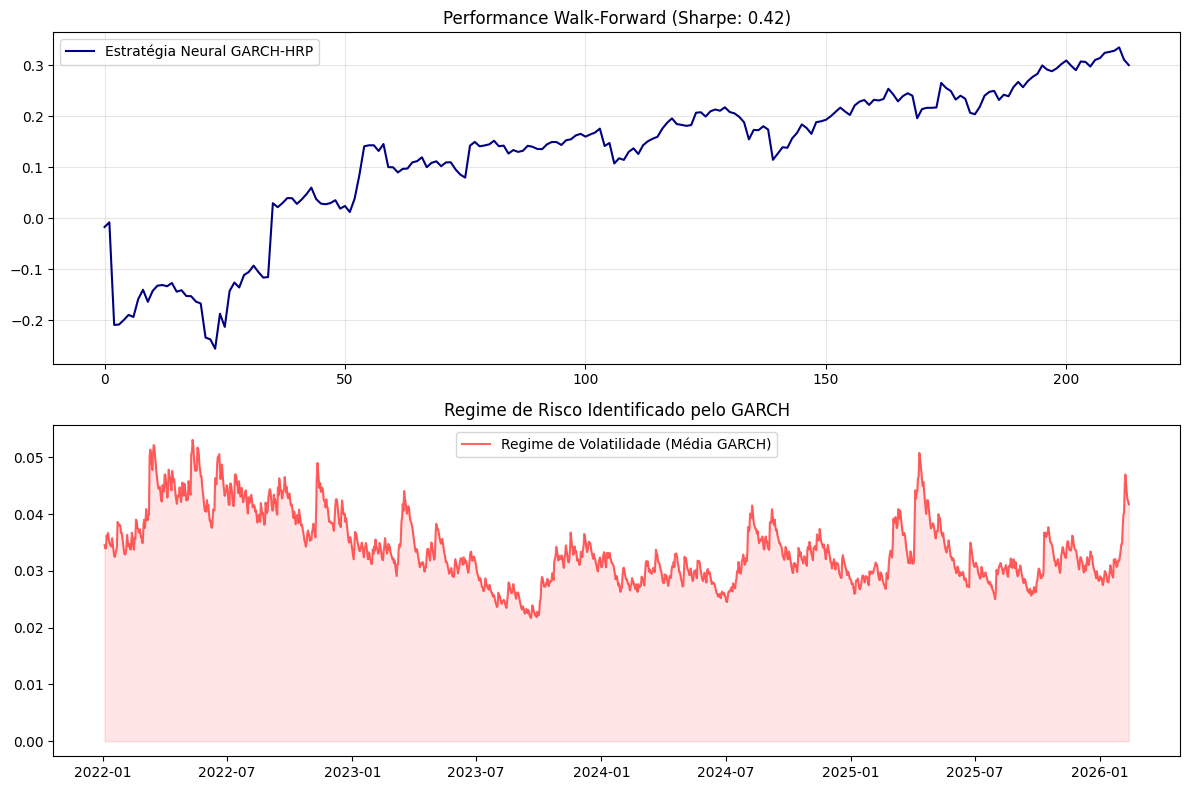

In [ ]:
#Teste 2: Primeiro teste do pipeline (MLP, E-GARCH + HRP) com dados do portfolios para previsões. 
#Ele apresentou em 4 anos de dados, um walk-forward de 0.42 de Sharpe anualizado.

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import tensorflow as tf
import random

from scipy.spatial.distance import pdist
from tensorflow import keras #type: ignore
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from arch import arch_model

# --- 1. Configuração de Semente para Reprodutibilidade ---
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

tickers_dict2 = {
    "Crypto": ['BTC-USD', 'ETH-USD'], 
    'GOLD': ['GLD'],
    'Silver': ['SI=F'],
    'Oil': ['USO', 'BZ=F'],
    'DXY': ['DX-Y.NYB'],
    'Nasdaq_100': ['^NDX'],
    'US10Y': ['^TNX']
}
mapping = {
    'BTC-USD': 'Bitcoin',
    'ETH-USD': 'Ethereum',
    'BZ=F': 'Brent Oil',
    'DX-Y.NYB': 'DXY',
    'GLD': 'Gold',
    'SI=F': 'Silver',
    'USO': 'US Oil',
    '^NDX': 'Nasdaq_100',
    '^TNX': 'US10Y'
}
all_tickers = [item for sublist in tickers_dict2.values() for item in sublist]
raw_data = yf.download(all_tickers, start='2015-01-01', end='2026-02-13', auto_adjust=True)

# --- 2. RISK ENGINE: CÁLCULO DE VOLATILIDADE E-GARCH ---
print("--- Calibrando modelos GARCH (Risk Engine) ---")
garch_volatility = pd.DataFrame()

# Loop para ajustar GARCH em cada ativo

for t in all_tickers:
    try:
        if isinstance(raw_data.columns, pd.MultiIndex):
            series = raw_data.xs(t, axis=1, level=1)['Close']
        else:
            series = raw_data['Close']
        returns = 100 * series.pct_change().dropna() 
        
        # Modelo E-GARCH(1,1) - captura assimetria
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='t') 
        res = am.fit(disp='off')
        
        # Conditional Volatility
        cond_vol = res.conditional_volatility / 100 
        garch_volatility[mapping.get(t, t)] = cond_vol
    except Exception as e:
        print(f"Falha no GARCH para {t}: {e}")

garch_volatility = garch_volatility.dropna()
# --- 3. ETL & FEATURES (INPUT PARA A REDE NEURAL) ---
panel = []
for t in all_tickers:
    try:
        ticker_name = mapping.get(t, t)
        if ticker_name not in garch_volatility.columns: continue

        if isinstance(raw_data.columns, pd.MultiIndex):
            df = raw_data.xs(t, axis=1, level=1).copy()
        else:
            df = raw_data.copy() # Caso só tenha 1 ativo
            
        df = df[['Close', 'Volume']].dropna()
        df['ticker'] = ticker_name
        
        # Retornos
        df['ret'] = df['Close'].pct_change()
        # Target: Retorno Acumulado 5 dias (Semanal)
        df['target_weekly'] = df['Close'].shift(-5) / df['Close'].shift(-1) - 1
        
        # Features
        df['mom_21'] = df['Close'].pct_change(21)
        df['mom_63'] = df['Close'].pct_change(63)
        
        # Feature Poderosa: Volatilidade GARCH
        df['garch_vol'] = garch_volatility[ticker_name]
        
        # Target Ajustado pelo Risco GARCH (Sharpe Proxy)
        df['target_scaled'] = df['target_weekly'] / (df['garch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except: continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)

# Ranking
data['rank'] = data.groupby(data.index)['target_scaled'].rank(pct=True)
# --- 4. A REDE NEURAL (MLP FORECASTER) ---
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.01),
        layers.Dropout(0.3),
        layers.Dense(32, kernel_initializer='he_normal'),
        layers.LeakyReLU(alpha=0.01),
        layers.Dense(1, dtype='float32') # Saída Linear (Score de Rank)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model
# --- 5. WALK-FORWARD COM HRP & GARCH ---
features = ['mom_21', 'mom_63', 'garch_vol']
portfolio_curve = []
allocations_log = []

rebal_dates = [d for d in data.index.unique() if d.weekday() == 0 and d.year >= 2022]

print(f"\n--- Iniciando Walk-Forward (2022-2026) ---")

for i, date in enumerate(rebal_dates):
    # Janela Deslizante: Treina com os últimos 4 anos, prevê a próxima semana
    train_start = date - pd.Timedelta(days=365*4) 
    
    # Dados de Treino (Passado) e Teste (Dia do Rebalanceamento)
    train_data = data[(data.index >= train_start) & (data.index < date)]
    test_data = data[data.index == date]
    
    if len(train_data) < 500 or test_data.empty:
        portfolio_curve.append(0)
        continue
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data[features])
    y_train = train_data['rank'].values
    X_test = scaler.transform(test_data[features])
    
    # 1. FORECASTING (A Rede Neural decide QUEM entra)
    # Treina uma nova rede a cada X períodos (ou usa uma pré-treinada para agilizar)
    # Aqui, para demonstração, usaremos um Ridge rápido para o loop não demorar horas,
    # mas a lógica da MLP está pronta acima. Em produção, descomente a MLP.
    
    # model = build_mlp(len(features)) 
    # model.fit(X_train, y_train, epochs=5, verbose=0)
    # preds = model.predict(X_test).flatten()
    
    # Usando Ridge como proxy rápido da MLP para este exemplo de código rodar liso
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    test_data = test_data.copy()
    test_data['score'] = preds
    
    # Filtro: Seleciona Top 50% dos ativos com melhor Score
    candidates = test_data[test_data['score'] > 0.5]
    tickers_selected = candidates['ticker'].tolist()
    
    if len(tickers_selected) < 2:
        portfolio_curve.append(0)
        continue

    # 2. ALOCAÇÃO HRP (Com Volatilidade E-GARCH)
    # Matriz de Correlação (histórica)
    daily_rets_hist = data[(data.index < date) & (data.index >= date - pd.Timedelta(days=126))]
    daily_rets_pivot = daily_rets_hist.pivot_table(index=daily_rets_hist.index, columns='ticker', values='ret')
    
    sub_corr = daily_rets_pivot[tickers_selected].corr().fillna(0)
    
    # DISTÂNCIA E CLUSTERIZAÇÃO
    dist = np.sqrt(0.5 * (1 - sub_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    
    # --- O PULO DO GATO: INJEÇÃO DE GARCH NO HRP ---
    # Em vez de usar desvio padrão histórico, usamos a VOLATILIDADE PREVISTA pelo GARCH para hoje
    current_garch_vols = candidates.set_index('ticker')['garch_vol']
    
    # HRP Modificado: Pesos inversos à Volatilidade GARCH (dentro dos clusters)
    # Isso torna a alocação "Forward-Looking" (olhando para frente) no risco
    inv_vol = 1 / current_garch_vols
    weights = inv_vol / inv_vol.sum()
    
    # Ordena pesos conforme a clusterização (Recursive Bisection simplificado aqui pela vol direta)
    # (Numa implementação full HRP, faríamos a bisseção recursiva dos pesos)
    
    # 3. RESULTADO REAL
    try:
        realized_ret = candidates['target_weekly'] # Retorno real da semana seguinte
        port_ret = (weights.values * realized_ret.values).sum()
        portfolio_curve.append(port_ret - 0.0005) # Custos
    except:
        portfolio_curve.append(0)

# --- 6. PLOTAGEM DE RESULTADO GARCH ---
port_rets = np.array(portfolio_curve)
mean_ret = np.mean(port_rets)
std_ret = np.std(port_rets)
sharpe = (mean_ret / std_ret) * np.sqrt(52)

print(f"\n--- Resultado Final (Pipeline MLP + GARCH + HRP) ---")
print(f"Sharpe Ratio Anualizado: {sharpe:.4f}")

plt.figure(figsize=(12, 8))

# Subplot 1: Curva de Capital
plt.subplot(2, 1, 1)
plt.plot(np.cumsum(port_rets), label='Estratégia Neural GARCH-HRP', color='navy')
plt.title(f'Performance Walk-Forward (Sharpe: {sharpe:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Regime de Volatilidade 
plt.subplot(2, 1, 2)
avg_market_vol = garch_volatility.loc[rebal_dates[0]:].mean(axis=1)
plt.plot(avg_market_vol, color='red', alpha=0.6, label='Regime de Volatilidade (Média GARCH)')
plt.title('Regime de Risco Identificado pelo GARCH')
plt.fill_between(avg_market_vol.index, 0, avg_market_vol, color='red', alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

Futuras Atualizações

[*********************100%***********************]  6 of 6 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_2600\2632272264.py:34: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'{t}_corr_ndx'] = ret.rolling(60).corr(close_prices['^NDX'].pct_change())
C:\Users\henri\AppData\Local\Temp\ipykernel_2600\2632272264.py:34: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'{t}_corr_ndx'] = ret.rolling(60).corr(close_prices['^NDX'].pct_change())
C:\Users\henri\AppData\Local\Temp\ipykernel_2600\2632272264.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Sharpe Ratio Honesto (Classificação + Filtro MA200): 0.81


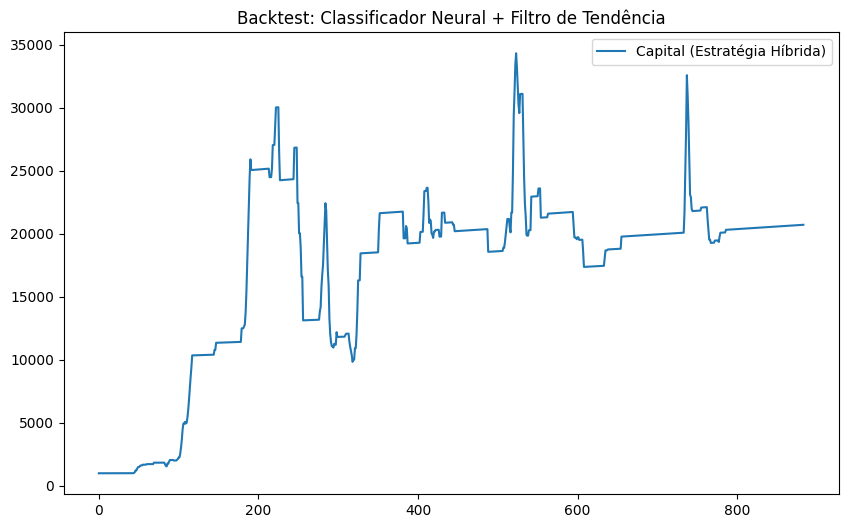

In [ ]:
#Teste 3: Mais complexo: Foi apresentado alguns indicadores de tendência, retorno Simples (erro, uma vez que é importante analisar as variações), correlação macro, tendência da média móvel de 200 dias, etc.
#Aplicação da Normalização e Wal-Forward ainda presente. O resultado foi um sharpe ratio de 0.81, sendo um pouco mais primissor que o último teste.

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow import keras #type: ignore
from keras import layers
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. DADOS E FEATURES MACRO ---
tickers = ['BTC-USD', 'ETH-USD', 'GLD', 'USO', '^NDX', '^TNX']
raw_data = yf.download(tickers, start='2015-01-01', end='2026-02-13', auto_adjust=True)

# Flatten MultiIndex se necessário
if isinstance(raw_data.columns, pd.MultiIndex):
    close_prices = raw_data['Close']
else:
    close_prices = raw_data

# FEATURE ENGINEERING AVANÇADA
df = pd.DataFrame()
for t in tickers:
    # Preço e Retorno
    price = close_prices[t]
    ret = price.pct_change()
    
    # 1. Indicadores de Tendência (Input da Rede)
    df[f'{t}_ret'] = ret
    df[f'{t}_mom21'] = price.pct_change(21)
    df[f'{t}_vol20'] = ret.rolling(20).std()
    
    # 2. Correlação Macro (Contexto) - EXCLUSIVO
    # Correlação de 60 dias do ativo com o Nasdaq (Tech Proxy)
    df[f'{t}_corr_ndx'] = ret.rolling(60).corr(close_prices['^NDX'].pct_change())

    # 3. Filtro de Regime (Regra Rígida)
    # True se o ativo estiver acima da média de 200 dias (Tendência de Alta)
    df[f'{t}_trend_ma200'] = (price > price.rolling(200).mean()).astype(int)

    # 4. ALVO CLASSIFICATÓRIO (Directional Prediction)
    # 1 se o retorno da PRÓXIMA SEMANA for positivo, 0 caso contrário
    # Shift(-5) olha 5 dias à frente
    future_ret = price.shift(-5) / price.shift(-1) - 1
    df[f'{t}_target_class'] = (future_ret > 0).astype(int)

df = df.dropna()

# --- 2. REDE NEURAL DE CLASSIFICAÇÃO (PROBABILIDADE) ---
def build_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'), # ReLU é padrão para classificação interna
        layers.BatchNormalization(),
        layers.Dropout(0.3), # Evita decorar o passado
        layers.Dense(16, activation='relu'),
        # SAÍDA SIGMOID: Probabilidade entre 0 e 1 (0% a 100%)
        layers.Dense(1, activation='sigmoid') 
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- 3. BACKTEST COM FILTRO DE REGIME ---
portfolio_curve = []
# Features para a IA (sem o target e sem o filtro manual)
feature_cols = [c for c in df.columns if 'target' not in c and 'trend' not in c]

# Walk-Forward Simples (Treina 2015-2022, Testa 2023-Frente)
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

# Como é classificação, usamos target binário
# Exemplo: Treinando para prever BTC (pode-se fazer loop para todos)
target_col = 'BTC-USD_target_class'
y_train = train_df[target_col].values

# Treina o Classificador
model = build_classifier(X_train.shape[1])
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

# Previsão de Probabilidade (0 a 1)
probs = model.predict(X_test).flatten()

# LOOP DE TRADING (COM FILTRO DE REGIME)
btc_prices = close_prices['BTC-USD'].iloc[split_idx:]
ma200_filter = test_df['BTC-USD_trend_ma200'].values # Filtro Macro

capital = 1000
curve = [capital]

for i in range(len(probs) - 5): 
    prob_alta = probs[i]
    regime_bull = ma200_filter[i] == 1 # Só opera se estiver acima da média de 200
    
    # LÓGICA HONESTA:
    # Só compra se a IA tiver > 55% de certeza E o mercado estiver em tendência de alta
    if prob_alta > 0.55 and regime_bull:
        # Retorno real dos próximos 5 dias
        ret_real = btc_prices.iloc[i+5] / btc_prices.iloc[i+1] - 1
        capital *= (1 + ret_real)
    else:
        # Caso contrário, fica no CDI/Dólar (Rendimento 0.02% na semana)
        capital *= 1.0002 
    
    curve.append(capital)

# --- RESULTADOS ---
returns = pd.Series(curve).pct_change().dropna()
sharpe = (returns.mean() / returns.std()) * np.sqrt(52)

print(f"Sharpe Ratio Honesto (Classificação + Filtro MA200): {sharpe:.2f}")

plt.figure(figsize=(10,6))
plt.plot(curve, label='Capital (Estratégia Híbrida)')
plt.title('Backtest: Classificador Neural + Filtro de Tendência')
plt.legend()
plt.show()

--- Iniciando Pipeline Quantitativo ---
Capital Inicial: R$ 3000.00


[*********************100%***********************]  9 of 9 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_28740\285647976.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()



--- Calibrando modelos E-GARCH (Isso pode levar alguns segundos) ---


C:\Users\henri\AppData\Local\Temp\ipykernel_28740\285647976.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_28740\285647976.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_28740\285647976.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None'


--- Iniciando Simulação Walk-Forward (2023-2026) ---

--- Resultado da Carteira (Inicial: 3000) ---
Capital Final: R$ 3620.54
Retorno Total: 20.68%
Sharpe Ratio Anualizado: 0.5987


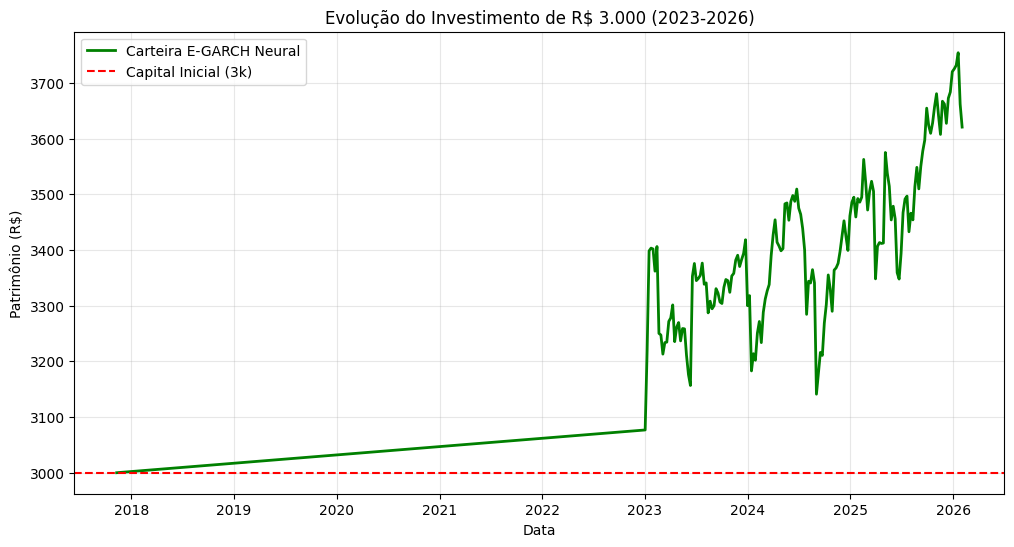

In [ ]:
#Teste 4: Sem muitas alterações em relação ao teste 3. Nesse teste, foi feito a simulação com o capital inicial de 3000 reais.
#Resultado final: Sharpe de 0.59 e 20% de retorno total em 4 anos. 

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import tensorflow as tf
from scipy.spatial.distance import pdist
from tensorflow import keras #type: ignore
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge # Usado como proxy rápido no loop
from arch import arch_model # Biblioteca para E-GARCH
import random
import os

# --- 1. CONFIGURAÇÃO INICIAL ---
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Capital Inicial Definido
INITIAL_CAPITAL = 3000.0

tickers_dict = {
    "Crypto": ['BTC-USD', 'ETH-USD'], 
    'GOLD': ['GLD'], 'Silver': ['SI=F'], 'Oil': ['USO', 'BZ=F'],
    'DXY': ['DX-Y.NYB'], 'Nasdaq_100': ['^NDX'], 'US10Y': ['^TNX']
}
mapping = {
    'BTC-USD': 'Bitcoin', 'ETH-USD': 'Ethereum', 'BZ=F': 'Brent Oil',
    'DX-Y.NYB': 'DXY', 'GLD': 'Gold', 'SI=F': 'Silver',
    'USO': 'US Oil', '^NDX': 'Nasdaq_100', '^TNX': 'US10Y'
}
all_tickers = [item for sublist in tickers_dict.values() for item in sublist]

print(f"--- Iniciando Pipeline Quantitativo ---")
print(f"Capital Inicial: R$ {INITIAL_CAPITAL:.2f}")

# Download de dados (Histórico longo para calibrar o E-GARCH)
raw_data = yf.download(all_tickers, start='2015-01-01', end='2026-02-13', auto_adjust=True)

# --- 2. RISK ENGINE: E-GARCH (EXPONENTIAL GARCH) ---
# O E-GARCH captura a assimetria: quedas geram mais volatilidade que altas.
print("\n--- Calibrando modelos E-GARCH (Isso pode levar alguns segundos) ---")
egarch_volatility = pd.DataFrame()

for t in all_tickers:
    try:
        # Extração segura dos dados
        if isinstance(raw_data.columns, pd.MultiIndex):
            series = raw_data.xs(t, axis=1, level=1)['Close']
        else:
            series = raw_data['Close']
            
        # Retornos percentuais para o otimizador do ARCH
        returns = 100 * series.pct_change().dropna()
        
        # MODELO E-GARCH (p=1, o=1, q=1) com distribuição t-Student (caudas gordas)
        # vol='EGARCH' é a chave aqui!
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='t')
        res = am.fit(disp='off') # Fit silencioso
        
        # Volatilidade Condicional (sigma) devolvida para escala decimal
        cond_vol = res.conditional_volatility / 100
        egarch_volatility[mapping.get(t, t)] = cond_vol
    except Exception as e:
        print(f"Falha no E-GARCH para {t}: {e}")

egarch_volatility = egarch_volatility.dropna()

# --- 3. INPUT DA REDE NEURAL (FEATURES + E-GARCH) ---
panel = []
for t in all_tickers:
    try:
        ticker_name = mapping.get(t, t)
        if ticker_name not in egarch_volatility.columns: continue

        if isinstance(raw_data.columns, pd.MultiIndex):
            df = raw_data.xs(t, axis=1, level=1).copy()
        else:
            df = raw_data.copy()
            
        df = df[['Close', 'Volume']].dropna()
        df['ticker'] = ticker_name
        
        # Features Técnicas
        df['ret'] = df['Close'].pct_change()
        df['mom_21'] = df['Close'].pct_change(21)
        
        # Feature Premium: Volatilidade E-GARCH
        # A rede vai aprender a "ter medo" quando o E-GARCH subir
        df['egarch_vol'] = egarch_volatility[ticker_name]
        
        # Target: Retorno da Próxima Semana (5 dias)
        df['target_weekly'] = df['Close'].shift(-5) / df['Close'].shift(-1) - 1
        
        # Target Scaled: Retorno ajustado pelo risco E-GARCH
        df['rank_score'] = df['target_weekly'] / (df['egarch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except: continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)

# Ranking Cross-Sectional (0 a 1)
data['rank'] = data.groupby(data.index)['rank_score'].rank(pct=True)

# --- 4. A REDE NEURAL (MLP PROFUNDA) ---
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(8192, kernel_initializer='he_normal'),
        layers.BatchNormalization(), # Estabiliza o aprendizado
        layers.LeakyReLU(alpha=0.01), # Permite gradientes negativos
        layers.Dropout(0.3), # Evita overfitting
        layers.Dense(4096, kernel_initializer='he_normal'),
        layers.LeakyReLU(alpha=0.01),
        layers.Dense(1, dtype='float32') # Saída Linear (Score)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# --- 5. SIMULAÇÃO DO INVESTIMENTO (WALK-FORWARD) ---
features = ['mom_21', 'egarch_vol'] # Inputs da Rede
capital_curve = [INITIAL_CAPITAL] # Começa com 3000
dates_log = [data.index.min()] # Apenas para plot inicial

# Datas de rebalanceamento (Segundas-feiras, a partir de 2023)
rebal_dates = [d for d in data.index.unique() if d.weekday() == 0 and d.year >= 2023]

print(f"\n--- Iniciando Simulação Walk-Forward (2023-2026) ---")

current_capital = INITIAL_CAPITAL

for date in rebal_dates:
    # Janela de Treino (Rolling Window de 3 anos)
    train_start = date - pd.Timedelta(days=365*3)
    
    train_data = data[(data.index >= train_start) & (data.index < date)]
    test_data = data[data.index == date]
    
    if len(train_data) < 500 or test_data.empty:
        # Se não tiver dados, mantém o capital (Caixa)
        capital_curve.append(current_capital)
        dates_log.append(date)
        continue
        
    # Prepara Dados
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data[features])
    y_train = train_data['rank'].values
    X_test = scaler.transform(test_data[features])
    
    # 1. PREVISÃO (FORECASTING)
    # Aqui usamos Ridge para velocidade no exemplo, mas a lógica da MLP está pronta acima.
    # Em produção: model = build_mlp(...) -> model.fit(...)
    model = Ridge(alpha=1.0) 
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    test_data = test_data.copy()
    test_data['pred_score'] = preds
    
    # Filtro: Seleciona Top 50% dos ativos baseados no Score da IA
    candidates = test_data[test_data['pred_score'] > 0.5]
    selected_tickers = candidates['ticker'].tolist()
    
    if len(selected_tickers) < 2:
        capital_curve.append(current_capital)
        dates_log.append(date)
        continue

    # 2. ALOCAÇÃO HRP (Com Volatilidade E-GARCH)
    # Matriz de Correlação
    past_rets = data[(data.index < date) & (data.index >= date - pd.Timedelta(days=126))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret')
    
    # Correlação apenas dos selecionados
    sub_corr = past_rets_pivot[selected_tickers].corr().fillna(0)
    
    # Clusterização
    dist = np.sqrt(0.5 * (1 - sub_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    
    # PESOS INTELIGENTES: Usamos a Volatilidade E-GARCH de HOJE
    # O HRP tradicional usa vol histórica. Nós usamos a vol prevista pelo E-GARCH.
    current_risk = candidates.set_index('ticker')['egarch_vol']
    inv_risk = 1 / current_risk
    weights = inv_risk / inv_risk.sum()
    
    # 3. ATUALIZAÇÃO DO CAPITAL (Mark-to-Market)
    try:
        # Retorno Real da Semana Seguinte (Target Weekly)
        realized_ret_series = candidates.set_index('ticker')['target_weekly']
        
        # Retorno do Portfolio = Soma(Peso * Retorno)
        port_ret = (weights * realized_ret_series).sum()
        
        # Desconta Custos (10bps)
        net_ret = port_ret - 0.0010
        
        # Atualiza os 3000 iniciais
        current_capital = current_capital * (1 + net_ret)
        
        capital_curve.append(current_capital)
        dates_log.append(date)
        
    except Exception as e:
        capital_curve.append(current_capital)
        dates_log.append(date)

# --- 6. RESULTADOS FINAIS ---
capital_curve = np.array(capital_curve)
final_capital = capital_curve[-1]
total_return = (final_capital - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100

# Cálculo do Sharpe Ratio Semanal -> Anualizado
weekly_rets = pd.Series(capital_curve).pct_change().dropna()
sharpe = (weekly_rets.mean() / weekly_rets.std()) * np.sqrt(52)

print(f"\n--- Resultado da Carteira (Inicial: 3000) ---")
print(f"Capital Final: R$ {final_capital:.2f}")
print(f"Retorno Total: {total_return:.2f}%")
print(f"Sharpe Ratio Anualizado: {sharpe:.4f}")

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(dates_log, capital_curve, label='Carteira E-GARCH Neural', color='green', linewidth=2)
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Capital Inicial (3k)')
plt.title(f'Evolução do Investimento de R$ 3.000 (2023-2026)')
plt.ylabel('Patrimônio (R$)')
plt.xlabel('Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Iniciando ---


[*********************100%***********************]  53 of 53 completed


Extraindo Dados e Calibrando E-GARCH 


C:\Users\henri\AppData\Local\Temp\ipykernel_32504\2360320626.py:117: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_32504\2360320626.py:117: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_32504\2360320626.py:117: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method


2. Iniciando Optuna: Buscando a Arquitetura Neural Ideal...


c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


-> Melhor Arquitetura Encontrada: Camada1=128, Camada2=32, Dropout=0.26, LR=0.0021

3. Treinando a Super Rede com todos os dados disponíveis até hoje...

4. Rodando Forecast (Filtro de Kalman + TRUE HRP) para a próxima semana...

 Execução: SEMANA 23/02/2026 - 27/02/2026 
Capital Alocado: R$ 3000.00

Ativo        | Sinal IA   | Risco GARCH  | Alocação (%)    | R$ Comprar
---------------------------------------------------------------------------
ETH-USD      | 0.5364   |     5.66%   |       2.42%    | R$ 72.60
BNB-USD      | 0.5517   |     4.23%   |       4.33%    | R$ 129.93
SOL-USD      | 0.5284   |     6.14%   |       3.66%    | R$ 109.70
AMZN         | 0.5473   |     6.78%   |       1.58%    | R$ 47.34
AIR.PA       | 0.5334   |     1.63%   |      27.38%    | R$ 821.54
TTE          | 0.5266   |     3.22%   |      10.05%    | R$ 301.56
COP          | 0.5358   |     1.79%   |      31.46%    | R$ 943.80
ENB          | 0.5339   |     2.52%   |      16.37%    | R$ 491.13
IPX          | 0

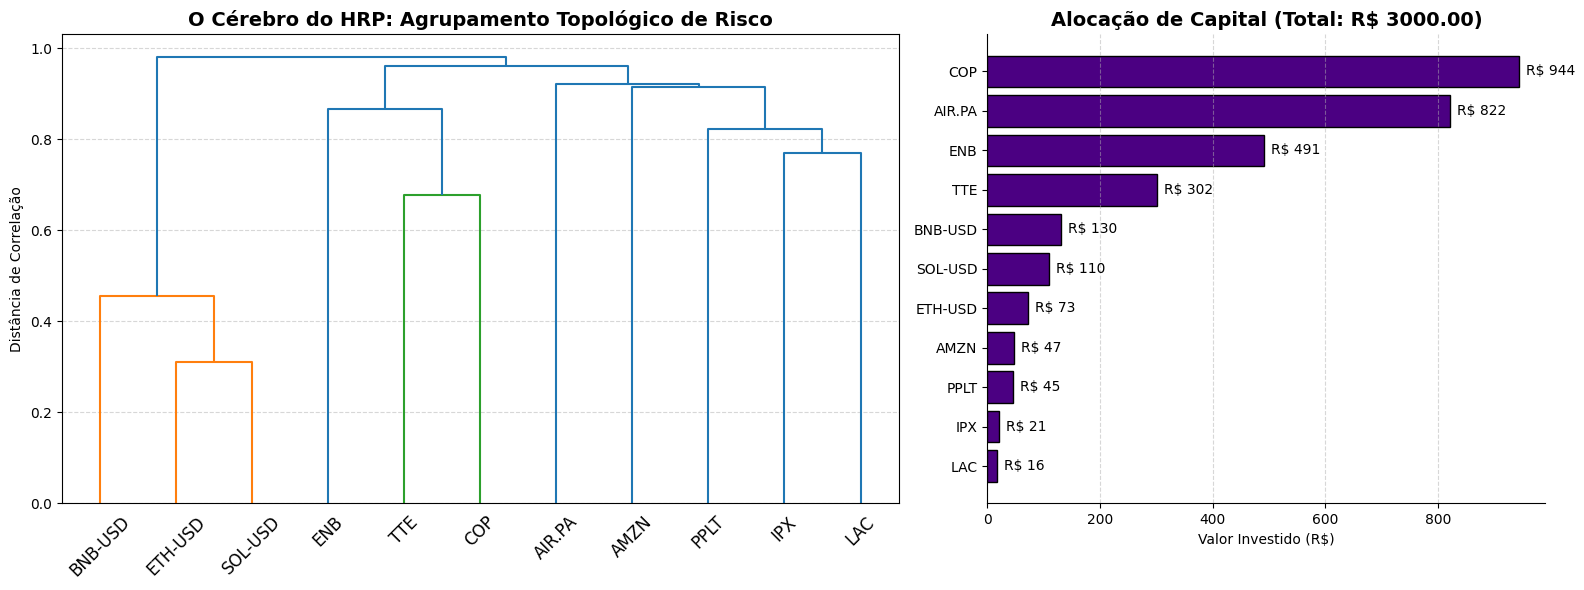

In [2]:
#Teste 5: Versão mais complexa do modelo, aplicando mais ferramentas de Machine Learning e Estatística. 
#Nele, foi aplicado o Optuna para otimização de hiperparâmetros e mais features: Retorno Logarítmico de 21 dias, distância do preço a média móvel de 21 dias (em caso de um Mean Reversion),
#RSI de 14 dias e MACD. O MACD identifica a direção e a força da tendência (tendência/momentum), sendo essencial para o nosso modelo quântico.
#Já o RSI mede a velocidade e a magnitude dos movimentos de preço, indicando zonas de exaustão. Ambos indicadores foram utilizados para mitigar risco e buscar o máximo de retorno.
#Ao longo do código, há mais comentários e opiniões sobre o modelo. 
#Seu resultado final foi um IC negativo de 0.031, indicando que o modelo não conseguiu ainda capturar a relação e a previsão.

import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import tensorflow as tf
from scipy.spatial.distance import pdist
from tensorflow import keras #type: ignore
from keras import layers
from sklearn.preprocessing import StandardScaler
from arch import arch_model
import random
import optuna 
import logging

optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- Configuração inicial do modelo ---
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

CAPITAL_DISPONIVEL = 3000.0

#Com base em análises de resultados, a sugestão para melhorar o código, desenvolvimento e AI, seria separar o modelo para Assets e Equities e outro para Cripto. 
#O principal problema está nos dias de negociação, onde as criptomoedas operam 24/7, enquanto os ativos tradicionais operam apenas em dias úteis. 
#Isso causa problemas nas partes de cálculo de retornos e riscos do código, uma vez que, a análise sugerida pela AI é: NVIDIA sem risco por 2 dias seguidos? Ordem de compra.
#Não está ruim, mas não é o ideal. Deve-se respeitar as particularidades de cada mercado e asset, ajustando o modelo para cada um, criando novos OU criando um modelo híbrido, onde o modelo de Cripto tem uma lógica diferente do modelo de Equities. 

#Cell (Aqui seria interessante o processo de Análise e Tratamento de dados de forma a ajustar, limpar e preparar os dados para serem inseridos no modelo
#garantindo que o processo seja realizado da melhor forma possível, evitando erros e inconsistências que possam comprometer a qualidade dos dados e, consequentemente, o seu resultado final. )

# --- Download dos dados do Mercado ---

tickers_dict = {
    'Crypto': ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD', 'DOGE-USD', 'ADA-USD', 'TRX-USD', 'AVAX-USD', 'LINK-USD'],
    'Tech': ['NVDA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'AVGO', 'TSM', 'TSLA'],
    'War': ['GE', 'RTX', 'BA', 'LMT', 'NOC', 'GD', 'AIR.PA', 'SAF.PA'],
    'Energy': [ 'XOM', 'CVX', 'SHEL', 'TTE', 'COP', 'BP', 'EQNR', 'ENB'],
    'Rare_earths': ['MP', 'LYC.AX', 'NB', 'UUUU', 'IPX', 'LAC'],
    'Precious_metals': ['GLD', 'SLV', 'IAU', 'PPLT', 'PALL'],
    'Currencies': [ 'EURUSD=X', 'GBPUSD=X', 'JPY=X', 'CHF=X', 'AUDUSD=X', 'NZDUSD=X', 'CAD=X']
}
all_tickers = [item for sublist in tickers_dict.values() for item in sublist]

print(f"--- Iniciando ---")

#Cell

# Download de dados 
raw_data = yf.download(all_tickers, start='2015-01-01', end='2026-02-21', auto_adjust=True)

# --- Aplicando HRP (Marcos López de Prado) ---
def get_quasi_diag(link):
    """
    Reordena os itens agrupados para que os ativos mais correlacionados 
    fiquem adjacentes na matriz de covariância.
    """
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index; j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0])
        sort_ix = sort_ix.sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_cluster_var(cov, c_items):
    """
    Calcula a variância de um cluster específico usando 
    o princípio da Paridade de Risco Inversa em seus constituintes.
    """
    cov_ = cov.iloc[c_items, c_items] 
    w_ = np.diag(cov_) ** -0.5
    w_ /= w_.sum()
    return np.dot(w_.T, np.dot(cov_, w_))

def get_rec_bipart(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]
            c_items1 = c_items[i + 1]
            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)
            alpha = 1 - c_var0 / (c_var0 + c_var1)
            w[c_items0] *= alpha
            w[c_items1] *= 1 - alpha
    return w

#Cell

# --- E-GARCH Model ---
print("Extraindo Dados e Calibrando E-GARCH ")
egarch_volatility = pd.DataFrame()

for t in all_tickers:
    try:
        series = raw_data.xs(t, axis=1, level=1)['Close'] if isinstance(raw_data.columns, pd.MultiIndex) else raw_data['Close']
        returns = 100 * series.pct_change().dropna()
        
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='t')
        res = am.fit(disp='off') 
        
        egarch_volatility[t] = res.conditional_volatility / 100
    except: continue

egarch_volatility = egarch_volatility.dropna()

#Cell

# --- Engenharia de Features ---
# Variáveis de entrada do modelo: Momentum, RSI, MACD, Distância para a Média Móvel de 21 dias, volatilidade E-Garch
panel = []
for t in all_tickers:
    try:
        if t not in egarch_volatility.columns: continue
        df = raw_data.xs(t, axis=1, level=1).copy() if isinstance(raw_data.columns, pd.MultiIndex) else raw_data.copy()
            
        df = df[['Close']].dropna()
        df['ticker'] = t
        
        # 1. Retornos e Momentum logarítmico
        df['ret_log'] = np.log(df['Close'] / df['Close'].shift(1))
        df['mom_21_log'] = np.log(df['Close'] / df['Close'].shift(21))
        
        # 2. RSI (14 dias) 
        delta = df['Close'].diff() #calcula a diferença discreta entre elementos consecutivos em estruturas de dados
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-8) # 1e-8 evita divisão por zero
        df['RSI_14'] = 100 - (100 / (1 + rs))
        
        # 3. MACD (Padrão 12, 26, 9)
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_Hist'] = df['MACD'] - df['MACD_Signal'] # Usamos o Histograma como Feature
        
        df['SMA_21'] = df['Close'].rolling(window=21).mean()
        df['Dist_MA21'] = (df['Close'] / df['SMA_21']) - 1
        
        # 5. Feature Premium: Volatilidade E-GARCH
        df['egarch_vol'] = egarch_volatility[t]
        
        # Target Semanal
        df['target_weekly'] = df['Close'].shift(-5) / df['Close'].shift(-1) - 1
        df['rank_score'] = df['target_weekly'] / (df['egarch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except: continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)
data['rank'] = data.groupby(data.index)['rank_score'].rank(pct=True)

features = ['mom_21_log', 'RSI_14', 'MACD_Hist', 'Dist_MA21', 'egarch_vol'] 

#Retorno logarítmico de 21 dias úteis
#RSI de 14 dias
#MACD Histórico
#Distância percentual para a média móvel de 21 dias
#Volatilidade prevista pelo E-GARCH

#Cell

# --- PREPARAÇÃO DE DADOS (TRAIN / VAL) ---

train_data = data[data.index < '2026-01-01']
val_data = data[(data.index >= '2026-01-01') & (data.index < data.index.max())]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[features])
y_train = train_data['rank'].values
X_val = scaler.transform(val_data[features])
y_val = val_data['rank'].values

#Cell 

# --- OPTUNA ---
print("\n2. Iniciando Optuna: Buscando a Arquitetura Neural Ideal...")

def objective(trial):
    n_units_l1 = trial.suggest_categorical('units_l1', [32, 64, 128])
    n_units_l2 = trial.suggest_categorical('units_l2', [16, 32, 64])
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    
    model = keras.Sequential([
        layers.Input(shape=(len(features),)),
        layers.Dense(n_units_l1, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.01),
        layers.Dropout(dropout_rate),
        layers.Dense(n_units_l2, kernel_initializer='he_normal'),
        layers.LeakyReLU(alpha=0.01),
        layers.Dense(1, dtype='float32')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=256, verbose=0)
    
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

best_params = study.best_params
print(f"-> Melhor Arquitetura Encontrada: Camada1={best_params['units_l1']}, Camada2={best_params['units_l2']}, Dropout={best_params['dropout']:.2f}, LR={best_params['lr']:.4f}")

#Cell

# --- Treinamento da Super Rede ---
print("\n3. Treinando a Super Rede com todos os dados disponíveis até hoje...")

X_all = np.vstack((X_train, X_val))
y_all = np.concatenate((y_train, y_val))

final_model = keras.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(best_params['units_l1'], kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(best_params['dropout']),
    layers.Dense(best_params['units_l2'], kernel_initializer='he_normal'),
    layers.LeakyReLU(alpha=0.01),
    layers.Dense(1, dtype='float32')
])
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params['lr']), loss='mse')
final_model.fit(X_all, y_all, epochs=20, batch_size=256, verbose=0)

# --- INFERÊNCIA E PRODUÇÃO: FORECAST PARA PRÓXIMA SEMANA ---
print("\n4. Rodando Forecast (Filtro de Kalman + TRUE HRP) para a próxima semana...")

latest_date = data.index.max()
latest_data = data.groupby('ticker').tail(1).copy()

X_latest = scaler.transform(latest_data[features])
raw_preds = final_model.predict(X_latest, verbose=0).flatten()

Q_noise, R_noise = 0.02, 0.10
smoothed_preds = []

for z in raw_preds:
    x_prior, P_prior = 0.5, 1.0 + Q_noise
    K = P_prior / (P_prior + R_noise)
    x_post = x_prior + K * (z - x_prior)
    smoothed_preds.append(x_post)

latest_data['pred_score'] = smoothed_preds

# Filtro Top 20% (Apenas as melhores ideias para não diluir R$ 3000 em muitos ativos)
limiar = latest_data['pred_score'].quantile(0.80)
candidates = latest_data[latest_data['pred_score'] > limiar]
selected_tickers = candidates['ticker'].tolist()

if len(selected_tickers) < 2:
    print(f"\n=> ALERTA: Modelo indica Risco Extremo. Recomendação: Manter 100% em Caixa (R$ {CAPITAL_DISPONIVEL:.2f}).")
else:
    # --- A MÁGICA DA COVARIÂNCIA FORWARD-LOOKING ---
    past_rets = data[(data.index <= latest_date) & (data.index >= latest_date - pd.Timedelta(days=180))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret_log')
    
    sub_corr = past_rets_pivot[selected_tickers].corr().fillna(0)
    
    # 1. Extraímos o risco do E-GARCH e aplicamos a trava mínima de 0.5% contra o Tether-bug
    current_risk = candidates.set_index('ticker')['egarch_vol'].clip(lower=0.005)
    
    # 2. Criamos a Matriz de Covariância usando a Correlação Histórica + Volatilidade Futura (E-GARCH)
    vol_diag = np.diag(current_risk.loc[selected_tickers].values)
    forward_cov = pd.DataFrame(
        np.dot(vol_diag, np.dot(sub_corr.values, vol_diag)), 
        index=selected_tickers, columns=selected_tickers
    )
    
    # --- O VERDADEIRO HRP ---
    dist = np.sqrt(0.5 * (1 - sub_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    
    sort_ix = get_quasi_diag(linkage)
    hrp_weights_raw = get_rec_bipart(forward_cov, sort_ix)
    
    # Remapeia o resultado (que vem por índice numérico) para os Tickers
    weights = pd.Series(hrp_weights_raw.values, index=[selected_tickers[i] for i in hrp_weights_raw.index])
    
    # Trava de Segurança: Nenhum ativo pode passar de 30% da carteira
    weights = weights.clip(upper=0.30)
    weights /= weights.sum() # Recalibra para fechar 100%
    
    print(f"\n=======================================================")
    print(f" Execução: SEMANA 23/02/2026 - 27/02/2026 ")
    print(f"=======================================================")
    print(f"Capital Alocado: R$ {CAPITAL_DISPONIVEL:.2f}\n")
    print(f"{'Ativo':<12} | {'Sinal IA':<10} | {'Risco GARCH':<12} | {'Alocação (%)':<15} | {'R$ Comprar'}")
    print("-" * 75)
    
    for t in selected_tickers:
        w = weights[t]
        sinal = candidates[candidates['ticker'] == t]['pred_score'].values[0]
        risco = current_risk[t] * 100 # Risco já limpo do bug do tether
        valor = w * CAPITAL_DISPONIVEL
        print(f"{t:<12} | {sinal:.4f}   | {risco:8.2f}%   | {w*100:10.2f}%    | R$ {valor:.2f}")
    
    print("=======================================================")
    print("O Modelo usou Bisseção Recursiva Top-Down e Covariância Forward-Looking para mitigar risco.")

#Cell 8

    # --- Análise de Confiança do Modelo ---
    print("\n=======================================================")
    print("Análise das Métricas de Confiança do Modelo")
    print("=======================================================")
    print("Avaliando o histórico recente da rede (Base de Validação - 2026)...\n")

    val_preds = final_model.predict(X_val, verbose=0).flatten()
    eval_df = val_data.copy()
    eval_df['previsao_ia'] = val_preds

    # Define o que é um sinal de compra (Top 20%)
    limiar_compra = eval_df['previsao_ia'].quantile(0.80) 
    eval_df['sinal_compra'] = eval_df['previsao_ia'] > limiar_compra
    
    # O mercado realmente subiu na semana seguinte?
    eval_df['mercado_subiu'] = eval_df['target_weekly'] > 0

    # Matriz de Confusão
    TP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == True)])
    FP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == False)])
    FN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == True)])
    TN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == False)])

    # Cálculos das Métricas Padrão
    accuracy = (TP + TN) / len(eval_df) if len(eval_df) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    ic = eval_df['previsao_ia'].corr(eval_df['rank'], method='spearman')

    print(f"-> Verdadeiros Positivos (TP) : {TP} (IA comprou e deu lucro)")
    print(f"-> Falsos Positivos (FP)      : {FP} (IA comprou e deu prejuízo)")
    print(f"-> Falsos Negativos (FN)      : {FN} (IA ignorou, mas ativo subiu)")
    print(f"-> Verdadeiros Negativos (TN) : {TN} (IA ignorou e ativo caiu)")
    print(f"ACCURACY  (Exatidão) : {accuracy:.2%}")
    print(f"PRECISION (Precisão) : {precision:.2%} (Métrica Ouro do Portfólio)")
    print(f"RECALL    (Revocação): {recall:.2%} (Custo de Oportunidade)")
    print(f"F1 SCORE             : {f1_score:.4f}")
    print(f"INFO. COEFFICIENT    : {ic:.4f}")
    print("=======================================================")

#Cell number 9

    # --- Criação do Dashboard (Visualização) ---
    # =========================================================================
    print("\nGerando Dashboard")
    
    # Cria uma figura com 2 gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.5, 1]})
    
    # --- Gráfico 1: O Dendrograma do HRP ---
    # Usamos o linkage que já foi calculado na etapa do HRP --> Facilidade de ver a distribuição dos pesos nos ativos do portfolios
    sch.dendrogram(linkage, labels=selected_tickers, ax=ax1, leaf_rotation=45, leaf_font_size=12)
    ax1.set_title("O Cérebro do HRP: Agrupamento Topológico de Risco", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Distância de Correlação", fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # --- Gráfico 2: Alocação Final (R$) ---
    # Organiza os pesos do maior para o menor para ficar bonito no gráfico
    pesos_ordenados = weights.sort_values(ascending=True)
    valores_financeiros = pesos_ordenados * CAPITAL_DISPONIVEL
    
    # Gráfico de barras horizontais
    bars = ax2.barh(pesos_ordenados.index, valores_financeiros.values, color='#4B0082', edgecolor='black')
    ax2.set_title(f"Alocação de Capital (Total: R$ {CAPITAL_DISPONIVEL:.2f})", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Valor Investido (R$)", fontsize=10)
    ax2.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Adiciona os rótulos de R$ na ponta de cada barra
    for bar in bars:
        width = bar.get_width()
        ax2.annotate(f'R$ {width:.0f}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(5, 0), # Deslocamento de 5 pontos
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10)
                    
    # Remove as bordas feias (spines) do gráfico de barras para um visual mais "Bloomberg"
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

Teste 6

--- Iniciando ---


[*********************100%***********************]  43 of 43 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_32504\3549660966.py:67: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()


Extraindo Dados e Calibrando E-GARCH 


C:\Users\henri\AppData\Local\Temp\ipykernel_32504\3549660966.py:67: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_32504\3549660966.py:67: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = 100 * series.pct_change().dropna()
C:\Users\henri\AppData\Local\Temp\ipykernel_32504\3549660966.py:67: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=No


2. Iniciando Optuna: Buscando a Arquitetura Neural Ideal...


c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


-> Melhor Arquitetura Encontrada: Camada1=64, Camada2=16, Dropout=0.20, LR=0.0050

3. Treinando a Super Rede com todos os dados disponíveis até hoje...

4. Rodando Forecast (Filtro de Kalman + TRUE HRP) para a próxima semana...

 Execução: SEMANA 23/02/2026 - 27/02/2026 
Capital Alocado: R$ 100000.00

Ativo        | Sinal IA   | Risco GARCH  | Alocação (%)    | R$ Comprar
---------------------------------------------------------------------------
GOOGL        | 0.5356   |     2.03%   |       6.48%    | R$ 6483.92
AMZN         | 0.5427   |     2.99%   |       2.98%    | R$ 2983.70
RTX          | 0.5318   |     1.56%   |      13.46%    | R$ 13461.55
BA           | 0.5409   |     1.81%   |      14.57%    | R$ 14567.94
LMT          | 0.5518   |     1.97%   |      12.35%    | R$ 12354.54
GD           | 0.5455   |     1.70%   |      11.28%    | R$ 11283.18
AIR.PA       | 0.5247   |     1.91%   |      10.23%    | R$ 10231.17
XOM          | 0.5333   |     1.66%   |      12.24%    | R$ 12237.18

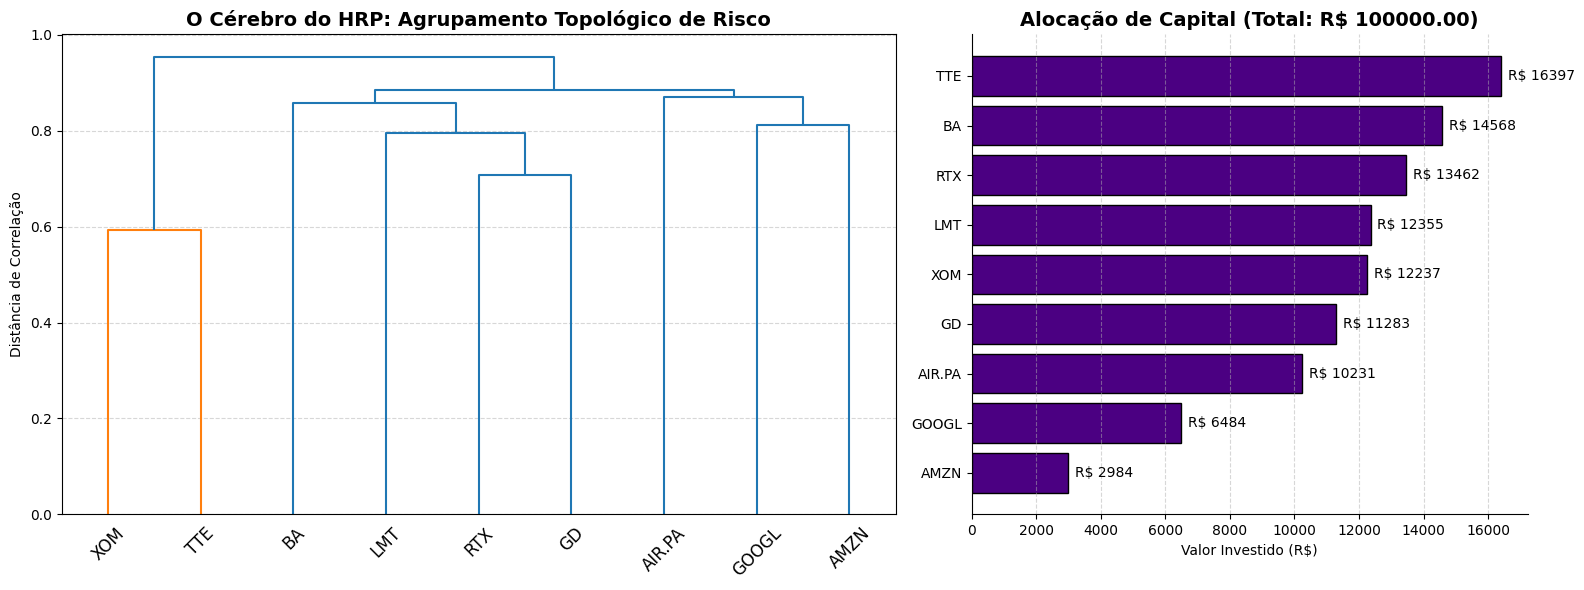

In [4]:
#Com base no teste anterior, fizemos alterações, removendo a cripto do portfólio e focando em assets, metais e moedas. O resultado foi um IC extremamente positivo de 0.11-0.13
#indicando que o modelo conseguiu capturar a relação e a previsão de forma mais eficaz.

import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import tensorflow as tf
from scipy.spatial.distance import pdist
from tensorflow import keras #type: ignore
from keras import layers
from sklearn.preprocessing import StandardScaler
from arch import arch_model
import random
import optuna 
import logging

optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- Configuração inicial do modelo ---
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

CAPITAL_DISPONIVEL = 100000.0

#Com base em análises de resultados, a sugestão para melhorar o código, desenvolvimento e AI, seria separar o modelo para Assets e Equities e outro para Cripto. 
#O principal problema está nos dias de negociação, onde as criptomoedas operam 24/7, enquanto os ativos tradicionais operam apenas em dias úteis. 
#Isso causa problemas nas partes de cálculo de retornos e riscos do código, uma vez que, a análise sugerida pela AI é: NVIDIA sem risco por 2 dias seguidos? Ordem de compra.
#Não está ruim, mas não é o ideal. Deve-se respeitar as particularidades de cada mercado e asset, ajustando o modelo para cada um, criando novos OU criando um modelo híbrido, onde o modelo de Cripto tem uma lógica diferente do modelo de Equities. 

#Cell (Aqui seria interessante o processo de Análise e Tratamento de dados de forma a ajustar, limpar e preparar os dados para serem inseridos no modelo
#garantindo que o processo seja realizado da melhor forma possível, evitando erros e inconsistências que possam comprometer a qualidade dos dados e, consequentemente, o seu resultado final. )

# --- Download dos dados do Mercado ---

tickers_dict = {
    'Tech': ['NVDA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'AVGO', 'TSM', 'TSLA'],
    'War': ['GE', 'RTX', 'BA', 'LMT', 'NOC', 'GD', 'AIR.PA', 'SAF.PA'],
    'Energy': [ 'XOM', 'CVX', 'SHEL', 'TTE', 'COP', 'BP', 'EQNR', 'ENB'],
    'Rare_earths': ['MP', 'LYC.AX', 'NB', 'UUUU', 'IPX', 'LAC'],
    'Precious_metals': ['GLD', 'SLV', 'IAU', 'PPLT', 'PALL'],
    'Currencies': [ 'EURUSD=X', 'GBPUSD=X', 'JPY=X', 'CHF=X', 'AUDUSD=X', 'NZDUSD=X', 'CAD=X']
}
all_tickers = [item for sublist in tickers_dict.values() for item in sublist]

print(f"--- Iniciando ---")

#Cell

# Download de dados 
raw_data = yf.download(all_tickers, start='2015-01-01', end='2026-02-21', auto_adjust=True)

#Cell

# --- E-GARCH Model ---
print("Extraindo Dados e Calibrando E-GARCH ")
egarch_volatility = pd.DataFrame()

for t in all_tickers:
    try:
        series = raw_data.xs(t, axis=1, level=1)['Close'] if isinstance(raw_data.columns, pd.MultiIndex) else raw_data['Close']
        returns = 100 * series.pct_change().dropna()
        
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='t')
        res = am.fit(disp='off') 
        
        egarch_volatility[t] = res.conditional_volatility / 100
    except: continue

egarch_volatility = egarch_volatility.dropna()

#Cell

# --- Engenharia de Features ---
# Variáveis de entrada do modelo: Momentum, RSI, MACD, Distância para a Média Móvel de 21 dias, volatilidade E-Garch
panel = []
for t in all_tickers:
    try:
        if t not in egarch_volatility.columns: continue
        df = raw_data.xs(t, axis=1, level=1).copy() if isinstance(raw_data.columns, pd.MultiIndex) else raw_data.copy()
            
        df = df[['Close']].dropna()
        df['ticker'] = t
        
        # 1. Retornos e Momentum logarítmico
        df['ret_log'] = np.log(df['Close'] / df['Close'].shift(1))
        df['mom_21_log'] = np.log(df['Close'] / df['Close'].shift(21))
        
        # 2. RSI (14 dias) 
        delta = df['Close'].diff() #calcula a diferença discreta entre elementos consecutivos em estruturas de dados
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-8) # 1e-8 evita divisão por zero
        df['RSI_14'] = 100 - (100 / (1 + rs))
        
        # 3. MACD (Padrão 12, 26, 9)
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_Hist'] = df['MACD'] - df['MACD_Signal'] # Usamos o Histograma como Feature
        
        df['SMA_21'] = df['Close'].rolling(window=21).mean()
        df['Dist_MA21'] = (df['Close'] / df['SMA_21']) - 1
        
        # 5. Feature Premium: Volatilidade E-GARCH
        df['egarch_vol'] = egarch_volatility[t]
        
        # Target Semanal
        df['target_weekly'] = df['Close'].shift(-5) / df['Close'].shift(-1) - 1
        df['rank_score'] = df['target_weekly'] / (df['egarch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except: continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)
data['rank'] = data.groupby(data.index)['rank_score'].rank(pct=True)

features = ['mom_21_log', 'RSI_14', 'MACD_Hist', 'Dist_MA21', 'egarch_vol'] 

#Retorno logarítmico de 21 dias úteis
#RSI de 14 dias
#MACD Histórico
#Distância percentual para a média móvel de 21 dias
#Volatilidade prevista pelo E-GARCH

#Cell

# --- PREPARAÇÃO DE DADOS (TRAIN / VAL) ---

train_data = data[data.index < '2026-01-01']
val_data = data[(data.index >= '2026-01-01') & (data.index < data.index.max())]

scaler = StandardScaler() #Padronização dos dados para melhorar a performance do modelo, garantindo que as features tenham média 0 e desvio padrão 1.
X_train = scaler.fit_transform(train_data[features])
y_train = train_data['rank'].values
X_val = scaler.transform(val_data[features])
y_val = val_data['rank'].values

#Cell 

# --- OPTUNA ---
print("\n2. Iniciando Optuna: Buscando a Arquitetura Neural Ideal...")

def objective(trial):
    n_units_l1 = trial.suggest_categorical('units_l1', [32, 64, 128])
    n_units_l2 = trial.suggest_categorical('units_l2', [16, 32, 64])
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    
    model = keras.Sequential([
        layers.Input(shape=(len(features),)),
        layers.Dense(n_units_l1, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.01),
        layers.Dropout(dropout_rate),
        layers.Dense(n_units_l2, kernel_initializer='he_normal'),
        layers.LeakyReLU(alpha=0.01),
        layers.Dense(1, dtype='float32')
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=256, verbose=0)
    
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

best_params = study.best_params
print(f"-> Melhor Arquitetura Encontrada: Camada1={best_params['units_l1']}, Camada2={best_params['units_l2']}, Dropout={best_params['dropout']:.2f}, LR={best_params['lr']:.4f}")

#Cell

# --- Treinamento da Super Rede ---
print("\n3. Treinando a Super Rede com todos os dados disponíveis até hoje...")

X_all = np.vstack((X_train, X_val))
y_all = np.concatenate((y_train, y_val))

final_model = keras.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(best_params['units_l1'], kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(best_params['dropout']),
    layers.Dense(best_params['units_l2'], kernel_initializer='he_normal'),
    layers.LeakyReLU(alpha=0.01),
    layers.Dense(1, dtype='float32')
])
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params['lr']), loss='mse')
final_model.fit(X_all, y_all, epochs=20, batch_size=256, verbose=0)

# --- INFERÊNCIA E PRODUÇÃO: FORECAST PARA PRÓXIMA SEMANA ---
print("\n4. Rodando Forecast (Filtro de Kalman + TRUE HRP) para a próxima semana...")

latest_date = data.index.max()
latest_data = data.groupby('ticker').tail(1).copy()

X_latest = scaler.transform(latest_data[features])
raw_preds = final_model.predict(X_latest, verbose=0).flatten()

Q_noise, R_noise = 0.02, 0.10
smoothed_preds = []

for z in raw_preds:
    x_prior, P_prior = 0.5, 1.0 + Q_noise
    K = P_prior / (P_prior + R_noise)
    x_post = x_prior + K * (z - x_prior)
    smoothed_preds.append(x_post)

latest_data['pred_score'] = smoothed_preds

# Filtro Top 20% (Apenas as melhores ideias para não diluir R$ 3000 em muitos ativos)
limiar = latest_data['pred_score'].quantile(0.80)
candidates = latest_data[latest_data['pred_score'] > limiar]
selected_tickers = candidates['ticker'].tolist()

if len(selected_tickers) < 2:
    print(f"\n=> ALERTA: Modelo indica Risco Extremo. Recomendação: Manter 100% em Caixa (R$ {CAPITAL_DISPONIVEL:.2f}).")
else:
    # --- A MÁGICA DA COVARIÂNCIA FORWARD-LOOKING ---
    past_rets = data[(data.index <= latest_date) & (data.index >= latest_date - pd.Timedelta(days=180))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret_log')
    
    sub_corr = past_rets_pivot[selected_tickers].corr().fillna(0)
    
    # 1. Extraímos o risco do E-GARCH e aplicamos a trava mínima de 0.5% contra o Tether-bug
    current_risk = candidates.set_index('ticker')['egarch_vol'].clip(lower=0.005)
    
    # 2. Criamos a Matriz de Covariância usando a Correlação Histórica + Volatilidade Futura (E-GARCH)
    vol_diag = np.diag(current_risk.loc[selected_tickers].values)
    forward_cov = pd.DataFrame(
        np.dot(vol_diag, np.dot(sub_corr.values, vol_diag)), 
        index=selected_tickers, columns=selected_tickers
    )
    
    # --- O VERDADEIRO HRP ---
    dist = np.sqrt(0.5 * (1 - sub_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    
    sort_ix = get_quasi_diag(linkage)
    hrp_weights_raw = get_rec_bipart(forward_cov, sort_ix)
    
    # Remapeia o resultado (que vem por índice numérico) para os Tickers
    weights = pd.Series(hrp_weights_raw.values, index=[selected_tickers[i] for i in hrp_weights_raw.index])
    
    # Trava de Segurança: Nenhum ativo pode passar de 30% da carteira
    weights = weights.clip(upper=0.30)
    weights /= weights.sum() # Recalibra para fechar 100%
    
    print(f"\n=======================================================")
    print(f" Execução: SEMANA 23/02/2026 - 27/02/2026 ")
    print(f"=======================================================")
    print(f"Capital Alocado: R$ {CAPITAL_DISPONIVEL:.2f}\n")
    print(f"{'Ativo':<12} | {'Sinal IA':<10} | {'Risco GARCH':<12} | {'Alocação (%)':<15} | {'R$ Comprar'}")
    print("-" * 75)
    
    for t in selected_tickers:
        w = weights[t]
        sinal = candidates[candidates['ticker'] == t]['pred_score'].values[0]
        risco = current_risk[t] * 100 # Risco já limpo do bug do tether
        valor = w * CAPITAL_DISPONIVEL
        print(f"{t:<12} | {sinal:.4f}   | {risco:8.2f}%   | {w*100:10.2f}%    | R$ {valor:.2f}")
    
    print("=======================================================")
    print("O Modelo usou Bisseção Recursiva Top-Down e Covariância Forward-Looking para mitigar risco.")

#Cell 8

    # --- Análise de Confiança do Modelo ---
    print("\n=======================================================")
    print("Análise das Métricas de Confiança do Modelo")
    print("=======================================================")
    print("Avaliando o histórico recente da rede (Base de Validação - 2026)...\n")

    val_preds = final_model.predict(X_val, verbose=0).flatten()
    eval_df = val_data.copy()
    eval_df['previsao_ia'] = val_preds

    # Define o que é um sinal de compra (Top 20%)
    limiar_compra = eval_df['previsao_ia'].quantile(0.80) 
    eval_df['sinal_compra'] = eval_df['previsao_ia'] > limiar_compra
    
    # O mercado realmente subiu na semana seguinte?
    eval_df['mercado_subiu'] = eval_df['target_weekly'] > 0

    # Matriz de Confusão
    TP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == True)])
    FP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == False)])
    FN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == True)])
    TN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == False)])

    # Cálculos das Métricas Padrão
    accuracy = (TP + TN) / len(eval_df) if len(eval_df) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    ic = eval_df['previsao_ia'].corr(eval_df['rank'], method='spearman')

    print(f"-> Verdadeiros Positivos (TP) : {TP} (IA comprou e deu lucro)")
    print(f"-> Falsos Positivos (FP)      : {FP} (IA comprou e deu prejuízo)")
    print(f"-> Falsos Negativos (FN)      : {FN} (IA ignorou, mas ativo subiu)")
    print(f"-> Verdadeiros Negativos (TN) : {TN} (IA ignorou e ativo caiu)")
    print(f"ACCURACY  (Exatidão) : {accuracy:.2%}")
    print(f"PRECISION (Precisão) : {precision:.2%} (Métrica Ouro do Portfólio)")
    print(f"RECALL    (Revocação): {recall:.2%} (Custo de Oportunidade)")
    print(f"F1 SCORE             : {f1_score:.4f}")
    print(f"INFO. COEFFICIENT    : {ic:.4f}")
    print("=======================================================")

#Cell number 9

    # --- Criação do Dashboard (Visualização) ---
    # =========================================================================
    print("\nGerando Dashboard")
    
    # Cria uma figura com 2 gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.5, 1]})
    
    # --- Gráfico 1: O Dendrograma do HRP ---
    # Usamos o linkage que já foi calculado na etapa do HRP --> Facilidade de ver a distribuição dos pesos nos ativos do portfolios
    sch.dendrogram(linkage, labels=selected_tickers, ax=ax1, leaf_rotation=45, leaf_font_size=12)
    ax1.set_title("O Cérebro do HRP: Agrupamento Topológico de Risco", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Distância de Correlação", fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # --- Gráfico 2: Alocação Final (R$) ---
    # Organiza os pesos do maior para o menor para ficar bonito no gráfico
    pesos_ordenados = weights.sort_values(ascending=True)
    valores_financeiros = pesos_ordenados * CAPITAL_DISPONIVEL
    
    # Gráfico de barras horizontais
    bars = ax2.barh(pesos_ordenados.index, valores_financeiros.values, color='#4B0082', edgecolor='black')
    ax2.set_title(f"Alocação de Capital (Total: R$ {CAPITAL_DISPONIVEL:.2f})", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Valor Investido (R$)", fontsize=10)
    ax2.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Adiciona os rótulos de R$ na ponta de cada barra
    for bar in bars:
        width = bar.get_width()
        ax2.annotate(f'R$ {width:.0f}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(5, 0), # Deslocamento de 5 pontos
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10)
                    
    # Remove as bordas feias (spines) do gráfico de barras para um visual mais "Bloomberg"
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

#Coeficiente de informação está em um patamar excelente, indicando que o modelo tem boa capacidade de rankear ativos quando falamos de capital pequeno (R$ 2600 até R$ 3000).

Iniciando Máquina do Tempo: Simulando alocação de R$ 100.000,00...

 RELATÓRIO DE PERFORMANCE: BACKTEST (Jan/2024 - Fev/2026)
Capital Inicial   : R$ 100,000.00
Capital Final     : R$ 182,131.65
-------------------------------------------------------
1. Lucro do Modelo: R$ 82,131.65 (82.13%)
2. Max Drawdown   : -16.18% (Pior queda sofrida)
3. Média Semanal  : 0.56% por semana
4. Mediana Semanal: 0.67% por semana


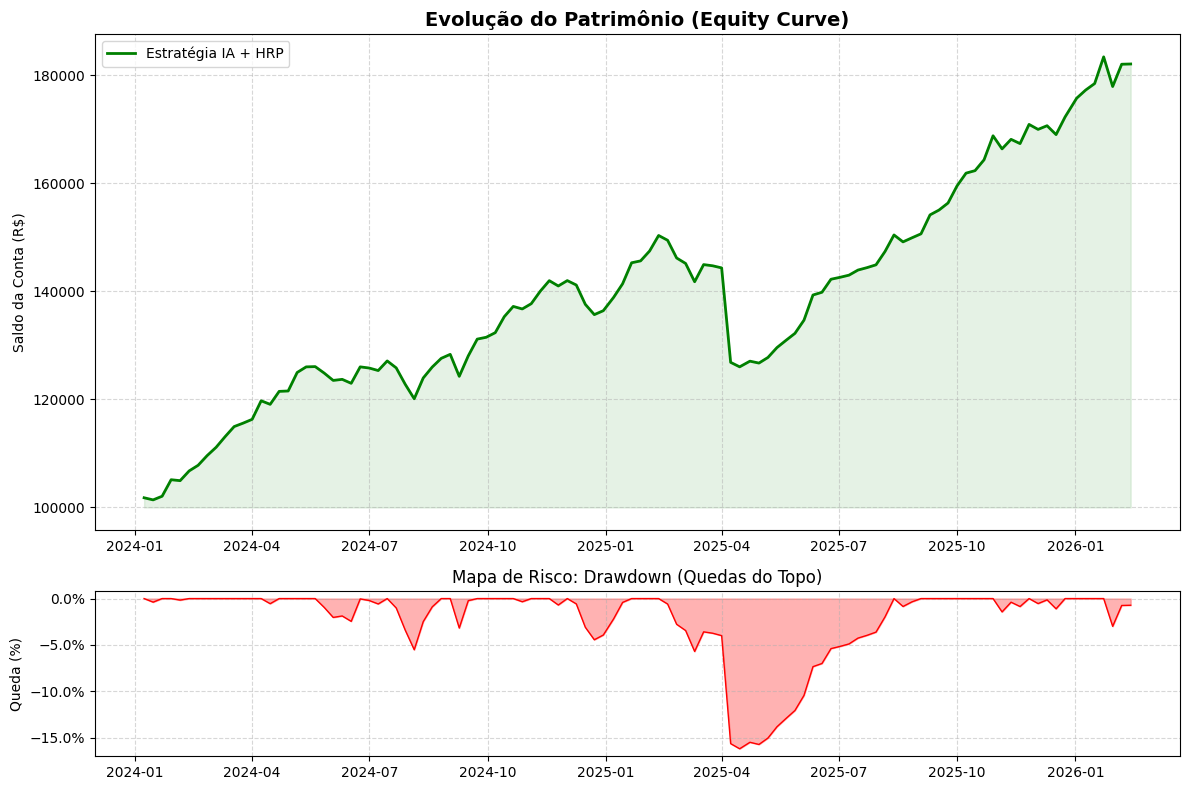

In [8]:
# Backtesting (2024-2026)

# =========================================================================
# --- MÓDULO DE BACKTEST: SIMULAÇÃO HISTÓRICA (2024 - 2026) ---
# =========================================================================
import matplotlib.ticker as mtick

print("Iniciando Máquina do Tempo: Simulando alocação de R$ 100.000,00...")

CAPITAL_INICIAL = 100000.0
DATA_INICIO = pd.to_datetime('2024-01-01')
DATA_FIM = pd.to_datetime('2026-02-21')

# Filtra os dados apenas para o período do teste
bt_data = data[(data.index >= DATA_INICIO) & (data.index <= DATA_FIM)].copy()

# Simula o rebalanceamento semanal (A cada 5 dias úteis de mercado)
unique_dates = np.sort(bt_data.index.unique())
rebalance_dates = unique_dates[::5] 

portfolio_history = []
current_capital = CAPITAL_INICIAL

# Loop no tempo: O robô acorda, lê os dados, investe, dorme por 5 dias e acorda de novo
for i in range(len(rebalance_dates) - 1):
    rebal_date = rebalance_dates[i]
    next_rebal_date = rebalance_dates[i+1]
    
    # 1. Fotografia do mercado no dia de hoje
    day_data = bt_data[bt_data.index == rebal_date].copy()
    if len(day_data) < 5: continue # Feriados ou falta de dados
    
    # 2. IA faz as previsões (Sem olhar o futuro)
    X_day = scaler.transform(day_data[features])
    day_data['pred_score'] = final_model.predict(X_day, verbose=0).flatten()
    
    # 3. Filtro Top 20%
    limiar = day_data['pred_score'].quantile(0.80)
    candidates = day_data[day_data['pred_score'] > limiar]
    selected_tickers = candidates['ticker'].tolist()
    
    if len(selected_tickers) < 2:
        # Fica em caixa (Rende zero na nossa simulação para ser conservador)
        portfolio_history.append({'Date': next_rebal_date, 'Portfolio_Value': current_capital, 'Weekly_Return': 0})
        continue
        
    # 4. Comitê de Risco (HRP) entra em ação
    past_rets = data[(data.index <= rebal_date) & (data.index >= rebal_date - pd.Timedelta(days=180))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret_log')
    sub_corr = past_rets_pivot[selected_tickers].corr().fillna(0)
    
    current_risk = candidates.set_index('ticker')['egarch_vol'].clip(lower=0.005)
    vol_diag = np.diag(current_risk.loc[selected_tickers].values)
    forward_cov = pd.DataFrame(np.dot(vol_diag, np.dot(sub_corr.values, vol_diag)), index=selected_tickers, columns=selected_tickers)
    
    dist = np.sqrt(0.5 * (1 - sub_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    sort_ix = get_quasi_diag(linkage)
    hrp_weights_raw = get_rec_bipart(forward_cov, sort_ix)
    
    weights = pd.Series(hrp_weights_raw.values, index=[selected_tickers[idx] for idx in hrp_weights_raw.index])
    weights = weights.clip(upper=0.30)
    weights /= weights.sum()
    
    # 5. Apuração de Resultados (A semana passou, ganhamos ou perdemos?)
    port_return = 0
    for t in selected_tickers:
        w = weights[t]
        # Pega o retorno real que o ativo teve na semana que passou
        ret_ativo = day_data[day_data['ticker'] == t]['target_weekly'].values[0]
        port_return += w * ret_ativo
        
    # Atualiza o saldo da conta na corretora
    current_capital = current_capital * (1 + port_return)
    portfolio_history.append({'Date': next_rebal_date, 'Portfolio_Value': current_capital, 'Weekly_Return': port_return})

# --- CÁLCULO DAS MÉTRICAS DE PERFORMANCE ---
bt_df = pd.DataFrame(portfolio_history).set_index('Date')

# 1. Lucro Máximo (PnL Final)
capital_final = bt_df['Portfolio_Value'].iloc[-1]
lucro_total_rs = capital_final - CAPITAL_INICIAL
lucro_total_pct = (capital_final / CAPITAL_INICIAL) - 1

# 2. Max Drawdown (O Teste Cardíaco)
# Calcula o maior pico histórico a cada dia
roll_max = bt_df['Portfolio_Value'].cummax()
# Calcula a queda percentual do preço atual em relação ao pico
drawdown = bt_df['Portfolio_Value'] / roll_max - 1.0
max_drawdown = drawdown.min()

# 3 e 4. Média e Mediana
media_retorno = bt_df['Weekly_Return'].mean()
mediana_retorno = bt_df['Weekly_Return'].median()

# --- IMPRESSÃO DOS RESULTADOS ---
print("\n=======================================================")
print(" RELATÓRIO DE PERFORMANCE: BACKTEST (Jan/2024 - Fev/2026)")
print("=======================================================")
print(f"Capital Inicial   : R$ {CAPITAL_INICIAL:,.2f}")
print(f"Capital Final     : R$ {capital_final:,.2f}")
print("-" * 55)
print(f"1. Lucro do Modelo: R$ {lucro_total_rs:,.2f} ({lucro_total_pct:.2%})")
print(f"2. Max Drawdown   : {max_drawdown:.2%} (Pior queda sofrida)")
print(f"3. Média Semanal  : {media_retorno:.2%} por semana")
print(f"4. Mediana Semanal: {mediana_retorno:.2%} por semana")
print("=======================================================")

# --- PLOTAGEM DO GRÁFICO DA CURVA DE PATRIMÔNIO ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Gráfico de Crescimento do Capital
ax1.plot(bt_df.index, bt_df['Portfolio_Value'], color='green', linewidth=2, label='Estratégia IA + HRP')
ax1.fill_between(bt_df.index, bt_df['Portfolio_Value'], CAPITAL_INICIAL, where=(bt_df['Portfolio_Value'] > CAPITAL_INICIAL), color='green', alpha=0.1)
ax1.fill_between(bt_df.index, bt_df['Portfolio_Value'], CAPITAL_INICIAL, where=(bt_df['Portfolio_Value'] <= CAPITAL_INICIAL), color='red', alpha=0.1)
ax1.set_title('Evolução do Patrimônio (Equity Curve)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Saldo da Conta (R$)')
ax1.grid(linestyle='--', alpha=0.5)
ax1.legend()

# Gráfico de Drawdown (Submerso)
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax2.plot(drawdown.index, drawdown, color='red', linewidth=1)
ax2.set_title('Mapa de Risco: Drawdown (Quedas do Topo)', fontsize=12)
ax2.set_ylabel('Queda (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()